# EDA: связь факторов риска с банковскими risk-level

## tl;dr

Анализ охватывает **200 разных контрагентов**: 100 из JSON и 100 из flattened CSV.

- `baseInfo.riskLevel` и `zskRiskLevel` связаны слабо: ordinal Spearman `ρ = 0.165`, quadratic weighted kappa `= 0.253`. Это не два названия одного и того же светофора.
- **Суды не повышают банковские risk-level в этой выборке.** При наличии raw-данных о делах ответчиком доля `MEDIUM/HIGH` равна примерно 12% против 19% без таких дел; для `YELLOW/RED` — 16% против 25%. Обратное направление не является «защитным эффектом»: оно статистически неустойчиво и смешано с возрастом/масштабом компании.
- **Активные исполнительные производства также не показывают устойчивой связи:** для `baseInfo` 19% против 15%, для ZSK 18% против 22%; точные тесты незначимы.
- Самая воспроизводимая связь с `baseInfo.riskLevel` — готовый negative signal `massAddress`: `MEDIUM/HIGH` у 43.5% компаний с сигналом против 12.3% без него, OR `= 5.49`, Fisher `p = 0.0007`. Направление повторяется и в JSON, и в CSV.
- Negative signals домена **ФНС / реестры** в целом связаны с `baseInfo.riskLevel` (36.6% против 10.5%), но почти не связаны с ZSK (23.8% против 20.3%). Это может быть частью алгоритма `baseInfo.riskLevel`, то есть потенциальной target leakage.
- Для ZSK заметна только предварительная гипотеза о возрасте: более молодые компании чаще имеют `YELLOW/RED` (`ρ = -0.202`, `p = 0.004`), но результат не проходит FDR 5% после проверки набора признаков.
- После FDR-коррекции ни один **сырой** судебный, исполнительный или финансовый признак не сохраняет уверенную связь с обоими target-полями.

Вывод: банковские risk-level и юридико-финансовые факторы отчёта отражают разные слои риска. Для продукта корректнее показывать их рядом, а не пытаться восстановить банковский светофор по данным отчёта.

## Context & Methods

Цель — проверить статистические связи между доступными признаками отчёта и двумя полями риска. Это **наблюдательный EDA**, поэтому далее используется слово «связь», а не причинное «влияние».

### Key Assumptions

1. Одна запись — один контрагент.
2. `UNKNOWN` в `baseInfo.riskLevel` исключается из ordinal- и binary-тестов: неизвестное значение не равно высокому риску.
3. Из-за редких классов (`HIGH=5`, `RED=2`) основные устойчивые endpoints бинарные:
   - base elevated: `MEDIUM/HIGH` против `LOW`;
   - ZSK elevated: `YELLOW/RED` против `GREEN`.
4. Slot-колонки CSV сначала собираются обратно на уровень компании. Индексы `[0]`, `[1]` не анализируются как самостоятельные признаки.
5. Готовые `reputationalRisks` отделены от raw facts: они могут уже участвовать в расчёте одного из target-полей.
6. Для финансов берётся последнее **доступное для конкретной метрики** значение и сохраняется его год.
7. Spearman `ρ` измеряет монотонную связь от `-1` до `1`. Fisher exact сравнивает доли для бинарных признаков. OR выше 1 означает большую долю elevated target при наличии признака. FDR/q-value снижает риск случайных находок при множественных тестах.

## Data

### 1. Setup and reproducibility

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf
from IPython.display import display
from scipy.stats import spearmanr
from statsmodels.stats.contingency_tables import StratifiedTable

project_root = next(
    candidate
    for candidate in [Path.cwd(), *Path.cwd().parents]
    if (candidate / "analysis/contractor_risk_eda.py").exists()
)
sys.path.insert(0, str(project_root))

from analysis.contractor_risk_eda import (
    binary_associations,
    build_feature_table,
    dataset_quality_summary,
    label_relationship,
    negative_domain_columns,
    numeric_associations,
    raw_binary_columns,
    raw_numeric_columns,
    signal_columns,
    top_replicated_associations,
)

JSON_PATH = Path("/Users/exoldoff/Downloads/contractors_audit.snapshot.json")
CSV_PATH = Path("/Users/exoldoff/Downloads/contractors_audit.snapshot_C12613591.csv")

assert JSON_PATH.exists(), JSON_PATH
assert CSV_PATH.exists(), CSV_PATH

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)
pd.options.display.float_format = "{:,.3f}".format
sns.set_theme(style="whitegrid", font_scale=0.95)

### 2. Load and normalize both sources

In [2]:
features = build_feature_table(JSON_PATH, CSV_PATH)
quality = dataset_quality_summary(features)

print(f"Компаний: {len(features)}")
print(f"Пересечение по ИНН между JSON и CSV: "
      f"{len(set(features.loc[features.dataset.eq('JSON'), 'inn']) & set(features.loc[features.dataset.eq('CSV'), 'inn']))}")
display(quality.round(1))

Компаний: 200
Пересечение по ИНН между JSON и CSV: 0


,dataset,companies,unique_inn,unique_ogrn,base_unknown,financials_available_pct,profit_available_pct,coefficients_available_pct,arbitration_yearly_nonempty_pct,arbitration_status_nonempty_pct,execution_amount_nonzero_pct,execution_amount_known_pct
0,JSON,100,100,100,3,67.000,33.000,19.000,32.000,38.000,50.000,80.100
1,CSV,100,100,100,3,69.000,39.000,28.000,35.000,43.000,42.000,61.500


Оба источника имеют одинаковый grain и не пересекаются по ИНН. Финансовые блоки разрежены: коэффициенты доступны лишь у 19% JSON и 28% CSV, прибыль — у 33% и 39%. Поэтому финансовые сравнения используют меньшую подвыборку и не равны анализу всех 200 компаний.

### 3. Target distribution

base_risk,HIGH,LOW,MEDIUM,UNKNOWN
dataset,,,,
CSV,1,85,11,3
JSON,4,78,15,3


zsk_risk,GREEN,RED,YELLOW
dataset,,,
CSV,77,1,22
JSON,81,1,18


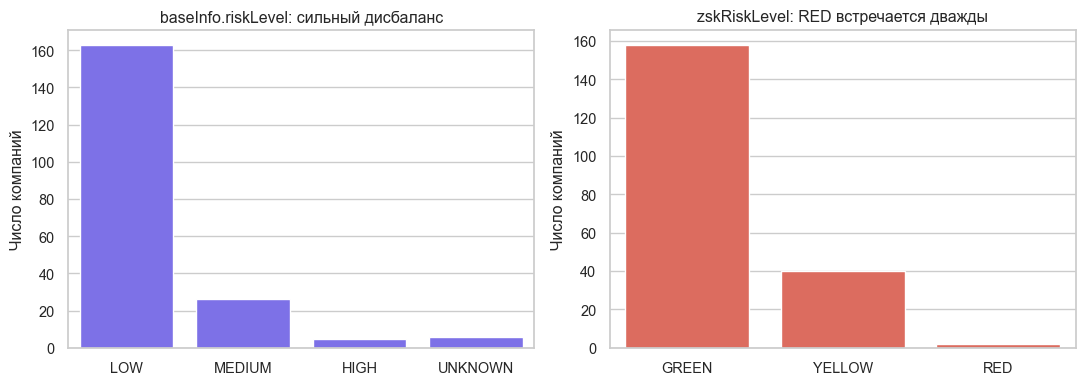

In [3]:
base_distribution = pd.crosstab(features["dataset"], features["base_risk"])
zsk_distribution = pd.crosstab(features["dataset"], features["zsk_risk"])
display(base_distribution)
display(zsk_distribution)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(data=features, x="base_risk", order=["LOW", "MEDIUM", "HIGH", "UNKNOWN"], ax=axes[0], color="#6D5DFB")
sns.countplot(data=features, x="zsk_risk", order=["GREEN", "YELLOW", "RED"], ax=axes[1], color="#F15B4A")
axes[0].set(title="baseInfo.riskLevel: сильный дисбаланс", xlabel="", ylabel="Число компаний")
axes[1].set(title="zskRiskLevel: RED встречается дважды", xlabel="", ylabel="Число компаний")
plt.tight_layout()
plt.show()

Редкие `HIGH` и `RED` нельзя анализировать как самостоятельные устойчивые классы. Любая «закономерность» по двум RED-компаниям будет зависеть от отдельных строк.

## Results

### 4. Связь двух risk-level между собой

In [4]:
relationship = label_relationship(features)
display(relationship["contingency"])
mapped_matches = (
    ((features.base_risk == "LOW") & (features.zsk_risk == "GREEN"))
    | ((features.base_risk == "MEDIUM") & (features.zsk_risk == "YELLOW"))
    | ((features.base_risk == "HIGH") & (features.zsk_risk == "RED"))
)
known_base = features.base_score.notna()

pd.DataFrame({
    "metric": ["N с известными targets", "Spearman rho", "Spearman p", "Quadratic weighted kappa", "Прямое соответствие классов, %"],
    "value": [relationship["n"], relationship["spearman_rho"], relationship["spearman_p"], relationship["weighted_kappa"], 100 * mapped_matches[known_base].mean()],
})

zsk_risk,GREEN,RED,YELLOW
base_risk,,,
HIGH,2,2,1
LOW,132,0,31
MEDIUM,18,0,8
UNKNOWN,6,0,0


,metric,value
0,N с известными targets,194.000
1,Spearman rho,0.165
2,Spearman p,0.021
3,Quadratic weighted kappa,0.253
4,"Прямое соответствие классов, %",73.196


Связь положительная, но слабая. В частности, 31 компания имеет `LOW + YELLOW`, а 18 — `MEDIUM + GREEN`. Полный Cramér's V здесь не выносится в headline: таблица содержит очень редкие ячейки, и две пары `HIGH + RED` искусственно усиливают категориальную метрику.

### 5. Raw risk domains against elevated targets

In [5]:
raw_binary = raw_binary_columns(features)
raw_base_binary = binary_associations(features, "base_elevated", raw_binary)
raw_zsk_binary = binary_associations(features, "zsk_elevated", raw_binary)

columns = ["feature_ru", "n", "support", "elevated_rate_with", "elevated_rate_without", "delta_pp", "risk_ratio", "p_value", "q_value"]
print("baseInfo elevated: лучшие raw binary связи")
display(raw_base_binary[columns].head(12).round(3))
print("ZSK elevated: лучшие raw binary связи")
display(raw_zsk_binary[columns].head(12).round(3))

baseInfo elevated: лучшие raw binary связи


,feature_ru,n,support,elevated_rate_with,elevated_rate_without,delta_pp,risk_ratio,p_value,q_value
12,есть проверки,194,56,0.054,0.203,-14.933,0.264,0.009,0.147
13,есть лицензии,194,19,0.000,0.177,-17.714,0.000,0.047,0.380
0,возраст компании ≤ 3 лет,194,69,0.217,0.128,8.939,1.698,0.151,0.552
1,есть арбитраж как ответчик,194,76,0.118,0.186,-6.802,0.635,0.234,0.552
14,не менее 10 дополнительных ОКВЭД,194,132,0.182,0.113,6.891,1.610,0.294,0.552
2,есть арбитраж как ответчик (yearly),194,62,0.113,0.182,-6.891,0.621,0.294,0.552
3,есть арбитраж как ответчик (status),194,75,0.120,0.185,-6.487,0.649,0.314,0.552
6,есть исполнительные производства,194,91,0.132,0.184,-5.260,0.715,0.335,0.552
8,отрицательная прибыль,68,9,0.000,0.169,-16.949,0.000,0.336,0.552
9,отрицательный капитал,130,10,0.000,0.167,-16.667,0.000,0.359,0.552


ZSK elevated: лучшие raw binary связи


,feature_ru,n,support,elevated_rate_with,elevated_rate_without,delta_pp,risk_ratio,p_value,q_value
12,есть проверки,200,59,0.102,0.255,-15.362,0.398,0.014,0.225
0,возраст компании ≤ 3 лет,200,70,0.300,0.162,13.846,1.857,0.029,0.229
2,есть арбитраж как ответчик (yearly),200,67,0.149,0.241,-9.135,0.620,0.146,0.562
1,есть арбитраж как ответчик,200,82,0.159,0.246,-8.723,0.645,0.160,0.562
13,есть лицензии,200,22,0.091,0.225,-13.381,0.405,0.176,0.562
3,есть арбитраж как ответчик (status),200,81,0.160,0.244,-8.320,0.659,0.215,0.574
4,есть арбитраж как истец,200,67,0.164,0.233,-6.890,0.704,0.277,0.634
9,отрицательный капитал,135,11,0.091,0.234,-14.296,0.389,0.455,0.829
15,есть заключённые госконтракты,200,12,0.083,0.218,-13.475,0.382,0.466,0.829
8,отрицательная прибыль,72,10,0.100,0.210,-10.968,0.477,0.675,1.000


Ни один raw binary-признак не проходит FDR 5%. Некоторые признаки показывают отрицательную связь (например, проверки или лицензии), но трактовать их как защитные нельзя: такие факты чаще встречаются у более зрелых и крупных компаний.

### 6. Суды и исполнительные производства — прямой spot check

In [6]:
legal_features = [
    "has_arbitration_defendant",
    "has_arbitration_defendant_yearly",
    "has_arbitration_defendant_status",
    "has_pending_defendant_cases",
    "has_active_execution",
]

legal_tables = []
for target, target_name in [("base_elevated", "base MEDIUM/HIGH"), ("zsk_elevated", "ZSK YELLOW/RED")]:
    table = binary_associations(features, target, legal_features)
    table.insert(0, "target_name", target_name)
    legal_tables.append(table)
legal = pd.concat(legal_tables, ignore_index=True)
display(legal[["target_name", "feature_ru", "n", "support", "elevated_rate_with", "elevated_rate_without", "delta_pp", "odds_ratio", "p_value", "q_value"]].round(3))

,target_name,feature_ru,n,support,elevated_rate_with,elevated_rate_without,delta_pp,odds_ratio,p_value,q_value
0,base MEDIUM/HIGH,есть арбитраж как ответчик,194,76,0.118,0.186,-6.802,0.586,0.234,0.475
1,base MEDIUM/HIGH,есть арбитраж как ответчик (yearly),194,62,0.113,0.182,-6.891,0.573,0.294,0.475
2,base MEDIUM/HIGH,есть арбитраж как ответчик (status),194,75,0.120,0.185,-6.487,0.601,0.314,0.475
3,base MEDIUM/HIGH,есть pending-дела как ответчик,194,24,0.083,0.171,-8.725,0.442,0.380,0.475
4,base MEDIUM/HIGH,есть активные исполнительные производства,194,31,0.194,0.153,4.017,1.325,0.595,0.595
5,ZSK YELLOW/RED,есть арбитраж как ответчик (yearly),200,67,0.149,0.241,-9.135,0.554,0.146,0.359
6,ZSK YELLOW/RED,есть арбитраж как ответчик,200,82,0.159,0.246,-8.723,0.578,0.160,0.359
7,ZSK YELLOW/RED,есть арбитраж как ответчик (status),200,81,0.160,0.244,-8.320,0.593,0.215,0.359
8,ZSK YELLOW/RED,есть активные исполнительные производства,200,33,0.182,0.216,-3.375,0.809,0.816,1.000
9,ZSK YELLOW/RED,есть pending-дела как ответчик,200,27,0.185,0.214,-2.869,0.835,1.000,1.000


Три судебных определения показаны отдельно:

- `yearly` — суммы `defendantCount` в `arbitrationCases`;
- `status` — finished + pending + appealed из `arbitrationByStatus`;
- общий флаг — наличие хотя бы в одном raw-блоке.

Во всех вариантах ожидаемой положительной связи с risk-level нет. При этом `arbitrationByStatus` находит больше компаний, чем готовый signal, поэтому бизнес-правило signal нельзя восстанавливать простым `count > 0` по всем судебным полям.

### 7. Existing signals and domain-level associations

,target,feature_ru,support,elevated_rate_with,elevated_rate_without,delta_pp,risk_ratio,p_value,q_value
0,base MEDIUM/HIGH,есть negative signal ФНС / реестров,41,0.366,0.105,26.128,3.498,0.000,0.001
1,base MEDIUM/HIGH,есть negative signal по арбитражу,62,0.113,0.182,-6.891,0.621,0.294,0.595
2,base MEDIUM/HIGH,есть negative signal по финансам,10,0.000,0.168,-16.848,0.000,0.369,0.595
3,base MEDIUM/HIGH,есть negative signal по ОКВЭД,44,0.114,0.173,-5.970,0.656,0.483,0.595
4,base MEDIUM/HIGH,есть negative signal по исполнительным делам,31,0.194,0.153,4.017,1.262,0.595,0.595
5,ZSK YELLOW/RED,есть negative signal по арбитражу,67,0.149,0.241,-9.135,0.620,0.146,0.730
6,ZSK YELLOW/RED,есть negative signal по ОКВЭД,45,0.267,0.194,7.312,1.378,0.303,0.757
7,ZSK YELLOW/RED,есть negative signal ФНС / реестров,42,0.238,0.203,3.556,1.176,0.671,1.000
8,ZSK YELLOW/RED,есть negative signal по исполнительным делам,33,0.182,0.216,-3.375,0.843,0.816,1.000
9,ZSK YELLOW/RED,есть negative signal по финансам,11,0.182,0.212,-2.982,0.859,1.000,1.000


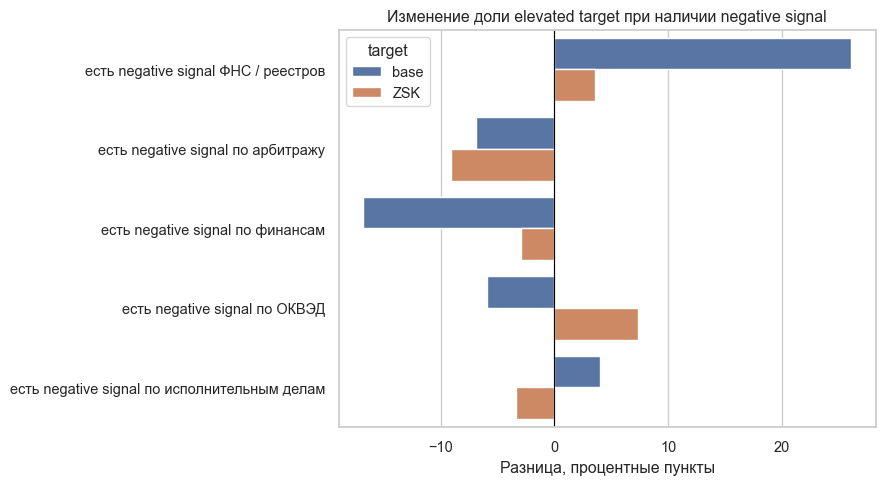

In [7]:
domain_features = negative_domain_columns(features)
domain_base = binary_associations(features, "base_elevated", domain_features)
domain_zsk = binary_associations(features, "zsk_elevated", domain_features)
domain_base.insert(0, "target", "base MEDIUM/HIGH")
domain_zsk.insert(0, "target", "ZSK YELLOW/RED")
domain_results = pd.concat([domain_base, domain_zsk], ignore_index=True)
display(domain_results[["target", "feature_ru", "support", "elevated_rate_with", "elevated_rate_without", "delta_pp", "risk_ratio", "p_value", "q_value"]].round(3))

plot_data = domain_results.copy()
plot_data["target"] = plot_data["target"].replace({"base MEDIUM/HIGH": "base", "ZSK YELLOW/RED": "ZSK"})
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=plot_data, y="feature_ru", x="delta_pp", hue="target", ax=ax)
ax.axvline(0, color="black", linewidth=0.8)
ax.set(title="Изменение доли elevated target при наличии negative signal", xlabel="Разница, процентные пункты", ylabel="")
plt.tight_layout()
plt.show()

Главное различие targets видно на домене реестров: он сильно связан с `baseInfo.riskLevel`, но не с ZSK. Это согласуется с тем, что два поля оценивают разные стороны риска.

### 8. `massAddress`: проверка повторяемости на двух источниках

In [8]:
mass_address = "neg_signal__massaddress"
mass_rows = []
strata = []
for dataset, subset in features.groupby("dataset"):
    result = binary_associations(subset, "base_elevated", [mass_address], min_support=5)
    row = result.iloc[0].to_dict()
    row["dataset"] = dataset
    mass_rows.append(row)

    exact = subset[[mass_address, "base_elevated"]].dropna().astype(int)
    table = pd.crosstab(exact[mass_address], exact["base_elevated"]).reindex(index=[1, 0], columns=[1, 0], fill_value=0)
    strata.append(table.to_numpy())

mass_by_source = pd.DataFrame(mass_rows)
display(mass_by_source[["dataset", "n", "support", "elevated_rate_with", "elevated_rate_without", "odds_ratio", "p_value"]].round(4))

mh = StratifiedTable(strata)
pd.DataFrame({
    "metric": ["Mantel-Haenszel OR", "95% CI low", "95% CI high", "p-value", "heterogeneity p"],
    "value": [mh.oddsratio_pooled, *mh.oddsratio_pooled_confint(), mh.test_null_odds().pvalue, mh.test_equal_odds().pvalue],
}).round(4)

,dataset,n,support,elevated_rate_with,elevated_rate_without,odds_ratio,p_value
0,CSV,97,11,0.364,0.093,5.571,0.028
1,JSON,97,12,0.500,0.153,5.538,0.011


,metric,value
0,Mantel-Haenszel OR,5.552
1,95% CI low,2.141
2,95% CI high,14.399
3,p-value,0.000
4,heterogeneity p,0.995


Связь `massAddress` с base target повторяется в обоих файлах и почти одинакова по силе. Но signal уже рассчитан поставщиком данных и может входить в формулу `baseInfo.riskLevel`. Поэтому это прежде всего **проверка согласованности слоёв**, а не новый независимый предиктор.

### 9. Numeric features and financial scale

baseInfo.riskLevel


,feature_ru,n,rho,p_value,q_value
15,коэффициент profitability,44,-0.349,0.020,0.190
11,последняя кредиторская задолженность,122,-0.203,0.025,0.190
7,последние активы,131,-0.195,0.025,0.190
26,число проверок,194,-0.193,0.007,0.190
9,последняя дебиторская задолженность,125,-0.181,0.043,0.232
27,число лицензий,194,-0.143,0.046,0.232
2,число филиалов,194,0.135,0.061,0.262
13,коэффициент sustainability,44,-0.265,0.083,0.310
14,коэффициент solvency,44,-0.246,0.107,0.315
6,последняя прибыль,68,-0.191,0.119,0.315


zskRiskLevel


,feature_ru,n,rho,p_value,q_value
0,"возраст компании, лет",200,-0.202,0.004,0.122
26,число проверок,200,-0.181,0.010,0.153
9,последняя дебиторская задолженность,130,-0.160,0.068,0.346
7,последние активы,136,-0.157,0.067,0.346
8,последний капитал,135,-0.154,0.074,0.346
5,последняя выручка,124,-0.153,0.090,0.346
11,последняя кредиторская задолженность,127,-0.148,0.096,0.346
19,число арбитражных дел как истец,200,-0.114,0.107,0.346
17,число арбитражных дел как ответчик (status),200,-0.110,0.122,0.346
18,сумма требований к компании в арбитраже,200,-0.108,0.127,0.346


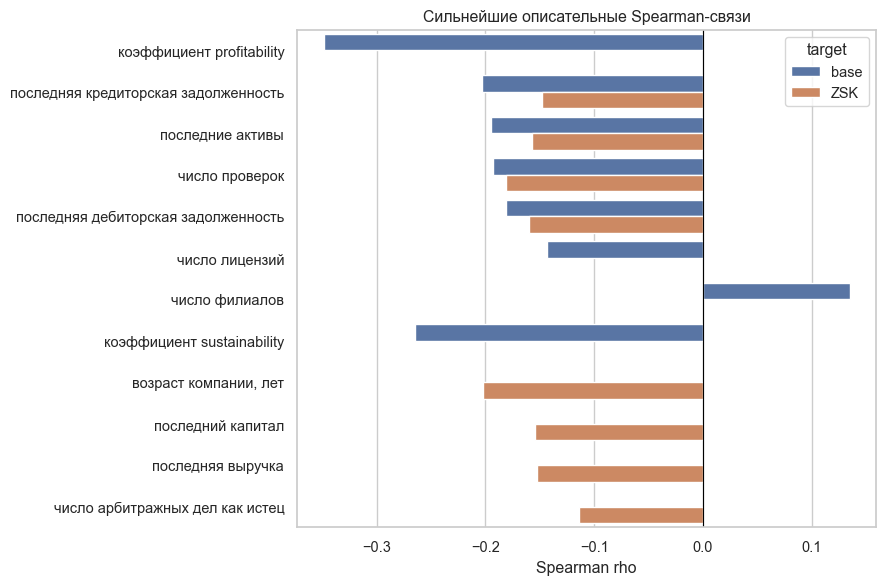

In [9]:
numeric_base = numeric_associations(features, "base_score", raw_numeric_columns(features))
numeric_zsk = numeric_associations(features, "zsk_score", raw_numeric_columns(features))

numeric_columns = ["feature_ru", "n", "rho", "p_value", "q_value"]
print("baseInfo.riskLevel")
display(numeric_base[numeric_columns].head(12).round(3))
print("zskRiskLevel")
display(numeric_zsk[numeric_columns].head(12).round(3))

top_numeric = pd.concat([
    numeric_base.assign(target="base").head(8),
    numeric_zsk.assign(target="ZSK").head(8),
])
fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=top_numeric, y="feature_ru", x="rho", hue="target", ax=ax)
ax.axvline(0, color="black", linewidth=0.8)
ax.set(title="Сильнейшие описательные Spearman-связи", xlabel="Spearman rho", ylabel="")
plt.tight_layout()
plt.show()

После FDR ни один raw numeric-признак не достигает `q < 0.05`. Отрицательные коэффициенты у активов, выручки и возраста скорее отражают связь повышенных уровней с меньшими/молодыми компаниями, а не самостоятельный эффект каждой суммы.

### 10. Возраст компании и возможный confounding

In [10]:
age_summary = features.groupby("zsk_risk")["company_age_years"].agg(["count", "median", "mean"])
display(age_summary.reindex(["GREEN", "YELLOW", "RED"]).round(2))

age_by_source = []
for dataset, subset in features.groupby("dataset"):
    rho, p = spearmanr(subset["company_age_years"], subset["zsk_score"], nan_policy="omit")
    age_by_source.append({"dataset": dataset, "rho": rho, "p_value": p})
display(pd.DataFrame(age_by_source).round(4))

age_bins = pd.cut(features["company_age_years"], bins=[-0.1, 0, 3, 7, np.inf], labels=["0", "1-3", "4-7", "8+"])
age_rates = features.assign(age_group=age_bins).groupby("age_group", observed=True)["zsk_elevated"].agg(["count", "mean"])
age_rates["elevated_pct"] = 100 * age_rates["mean"]
display(age_rates[["count", "elevated_pct"]].round(1))

confounding = features.groupby("has_inspections")["company_age_years"].agg(["count", "median", "mean"])
print("Возраст компаний без/с проверками:")
display(confounding.round(2))

,count,median,mean
zsk_risk,,,
GREEN,158,6.500,8.580
YELLOW,40,4.500,5.600
RED,2,0.500,0.500


,dataset,rho,p_value
0,CSV,-0.169,0.093
1,JSON,-0.235,0.019


,count,elevated_pct
age_group,,
0,18,50.000
1-3,52,23.100
4-7,51,19.600
8+,79,13.900


Возраст компаний без/с проверками:


,count,median,mean
has_inspections,,,
0,141,4.000,6.260
1,59,10.000,11.830


Возраст показывает одинаковое отрицательное направление в обоих источниках, но после FDR остаётся гипотезой. Проверки, суды, лицензии и исполнительные производства чаще встречаются у старых компаний; поэтому их «обратная» связь с ZSK частично объясняется смешением факторов.

### 11. Signal consistency and missing-data risks

In [11]:
consistency = pd.DataFrame([
    {
        "comparison": "active execution raw vs negative signal",
        "raw_positive": int(features["has_active_execution"].sum()),
        "signal_positive": int(features["neg_signal__executionproceedings"].sum()),
        "agreement_pct": 100 * (features["has_active_execution"] == features["neg_signal__executionproceedings"]).mean(),
    },
    {
        "comparison": "arbitration yearly raw vs negative signal",
        "raw_positive": int(features["has_arbitration_defendant_yearly"].sum()),
        "signal_positive": int(features["neg_signal__arbitrationdefendant"].sum()),
        "agreement_pct": 100 * (features["has_arbitration_defendant_yearly"] == features["neg_signal__arbitrationdefendant"]).mean(),
    },
    {
        "comparison": "arbitration status raw vs negative signal",
        "raw_positive": int(features["has_arbitration_defendant_status"].sum()),
        "signal_positive": int(features["neg_signal__arbitrationdefendant"].sum()),
        "agreement_pct": 100 * (features["has_arbitration_defendant_status"] == features["neg_signal__arbitrationdefendant"]).mean(),
    },
])
display(consistency.round(1))

raw_csv = pd.read_csv(CSV_PATH, dtype=str)
csv_missingness = raw_csv.isna().mean()
report_dates = pd.to_datetime(features["report_date"], errors="coerce", utc=True)

quality_facts = pd.DataFrame({
    "check": [
        "Средняя доля пропусков в flattened CSV",
        "CSV-колонки с >=95% пропусков",
        "CSV-колонки с >=80% пропусков",
        "Минимальная дата отчёта",
        "Максимальная дата отчёта",
    ],
    "value": [
        f"{100 * csv_missingness.mean():.1f}%",
        int((csv_missingness >= 0.95).sum()),
        int((csv_missingness >= 0.80).sum()),
        str(report_dates.min().date()),
        str(report_dates.max().date()),
    ],
})
display(quality_facts)

heavy_tail = features.groupby("dataset")[["execution_total_count", "inspection_count", "related_companies_count", "other_okved_count"]].quantile([0.5, 0.9, 0.99, 1.0]).unstack(0)
display(heavy_tail.round(1))

,comparison,raw_positive,signal_positive,agreement_pct
0,active execution raw vs negative signal,33,33,100.000
1,arbitration yearly raw vs negative signal,67,67,100.000
2,arbitration status raw vs negative signal,81,67,92.000


,check,value
0,Средняя доля пропусков в flattened CSV,91.4%
1,CSV-колонки с >=95% пропусков,1950
2,CSV-колонки с >=80% пропусков,2396
3,Минимальная дата отчёта,2026-07-29
4,Максимальная дата отчёта,2026-08-27


execution_total_count           inspection_count         related_companies_count        other_okved_count        
dataset                   CSV      JSON              CSV    JSON                     CSV   JSON               CSV    JSON
0.500                   0.000     1.000            0.000   0.000                   1.000  1.000            16.000  16.000
0.900                  23.100    28.900            4.100   4.100                   4.000  7.000            43.200  47.300
0.990                 163.000   522.300           31.200 100.000                  13.000 28.100            80.100  85.400
1.000                 459.000 1,744.000           48.000 100.000                  17.000 34.000            89.000 120.000

Flat CSV разрежен конструктивно: массивы разложены на тысячи slot-колонок. Прямой перебор всех 2654 полей дал бы множество ложных находок и артефактов порядка элементов.

Отдельно важна неоднозначность missing/zero. Для `arbitrationCases` yearly-флаг полностью совпадает с готовым signal, но `arbitrationByStatus` находит дополнительные raw cases. Следовательно, разные блоки имеют разные правила/охват, и «пусто» нельзя безоговорочно считать доказанным отсутствием риска.

## Takeaways

1. **Не использовать `baseInfo.riskLevel` и `zskRiskLevel` как взаимозаменяемые labels.** Их связь слабая, а бизнес-определения пока неизвестны.
2. **Не обучать scoring на 2654 CSV-колонках.** Сначала нормализовать до компании и заранее определить 20–30 осмысленных агрегатов.
3. **Суды и исполнительные производства показывать отдельным AI-слоем**, даже если банковский risk-level зелёный/низкий: отсутствие корреляции здесь и есть продуктовая ценность дополнительного анализа.
4. **Реестровые negative signals связаны с `baseInfo.riskLevel`**, особенно `massAddress`, но это потенциальная target leakage. Нужно спросить кейсодателя, участвуют ли signals в расчёте поля.
5. **ZSK почти не объясняется юридическими и репутационными данными отчёта.** Предварительная связь с молодым возрастом требует подтверждения на большей выборке.
6. **Для deterministic analytics хранить availability/evidence рядом с каждой метрикой:** source path, год, raw value и правило агрегации.
7. Для будущих evals анализировать не «угадал ли агент светофор», а корректно ли он нашёл raw facts, выделил domain risks, сослался на evidence и честно обработал missing data.

### Что нужно уточнить у кейсодателя

- Какое поле является банковским светофором и как определяется второе?
- Входит ли `reputationalRisks` в расчёт `baseInfo.riskLevel`?
- Чем объясняется различие `arbitrationCases`, `arbitrationByStatus` и готового arbitration signal?
- Означает ли отсутствие блока «факт отсутствует» или «данные не получены»?